# LSTM Notebook

This notebook provides an example of working with the LSTM model. It
shows the process of loading per-game data for premier league forwards for
the current season, splitting into train/test sets, creating datasets and
dataloaders from them, training a `FootballLSTM` instance, and evaluating
it.

In [1]:
import sys
import os
from understatapi import UnderstatClient
import torch
from torch.utils.data import DataLoader
import torch.nn as nn

# Also import local helpers
target_dir = os.path.abspath('..') 

if target_dir not in sys.path:
    sys.path.append(target_dir)
    
from preprocess import get_position_players_stats_df, CustomFootballDataset
from football_lstm import FootballLSTM

In [2]:
# Create understat connection
understat = UnderstatClient()

In [3]:
# Choose what stats to forecast, and how many past games to use to predict
# the current one
stats = ["goals", "xG", "assists", "xA", "key_passes", "xGChain", "xGBuildup"]
window_size = 10

In [4]:
# Get forward stats for 2025 PL season
f_stats = get_position_players_stats_df(understat, ['F'], stats)
f_stats.head()

goals_per_90  xG_per_90  assists_per_90  xA_per_90  \
player_id date                                                             
8260      2020-01-18      8.181818   3.607609             0.0   0.000000   
          2020-01-24      7.826087   5.217378             0.0   0.000000   
          2020-02-01      2.337662   0.915153             0.0   0.079898   
          2020-02-08      0.000000   0.106622             0.0   0.000000   
          2020-02-14      1.125000   0.780861             0.0   0.052143   

                      key_passes_per_90  xGChain_per_90  xGBuildup_per_90  
player_id date                                                             
8260      2020-01-18           0.000000        3.670909          0.063311  
          2020-01-24           0.000000        5.217378          0.000000  
          2020-02-01           1.168831        0.918955          0.656944  
          2020-02-08           0.000000        0.422343          0.363373  
          2020-02-14           1.125000        0.885026          0.052023

In [5]:
# Train/test split
train_len = int(len(f_stats) * 0.8)
train_df = f_stats.iloc[:train_len]
test_df = f_stats.iloc[train_len:]

In [6]:
# Create datasets
train_dataset = CustomFootballDataset(train_df, window_size, multiple_players=False)
test_dataset = CustomFootballDataset(test_df, window_size, multiple_players=False)

In [7]:
# Create dataloaders

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [8]:
# Initialize model
model = FootballLSTM(n_features=len(f_stats.columns), hidden_size=32)

In [9]:
# Loss function, optimizer, epochs
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 20

In [10]:
# Train model

model.train_model(
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    n_epochs=num_epochs
)

Train total loss: 3280.7757785618305
Test total loss: 1349.3421265482903
Train total loss: 3222.0829126536846
Test total loss: 1349.2509253919125
Train total loss: 3219.865399926901
Test total loss: 1346.2206167578697
Train total loss: 3216.4360746890306
Test total loss: 1344.1852423250675
Train total loss: 3217.342159330845
Test total loss: 1347.0679429769516
Train total loss: 3222.2980971336365
Test total loss: 1345.0476234555244
Train total loss: 3213.2608805298805
Test total loss: 1346.3264962732792
Train total loss: 3212.177952617407
Test total loss: 1344.2960192263126
Train total loss: 3210.1176247298717
Test total loss: 1343.4721053540707
Train total loss: 3208.8532585799694
Test total loss: 1345.168650150299
Train total loss: 3206.877252370119
Test total loss: 1344.9888557195663
Train total loss: 3209.934838205576
Test total loss: 1344.3833665251732
Train total loss: 3203.7660433351994
Test total loss: 1344.6758279502392
Train total loss: 3203.1750060617924
Test total loss: 134

In [11]:
# Evaluate test performance

model.eval_model(test_dataloader)

Test RMSE: 3.3044674396514893
Test MAE: 0.8409347534179688


RMSE: 0.780059814453125
MAE: 0.5795542001724243
goals_per_90 RMSE: 1.3706316947937012
goals_per_90 MAE: 0.9733714461326599
xG_per_90 RMSE: 1.005650281906128
xG_per_90 MAE: 0.7436395883560181
assists_per_90 RMSE: 0.527805745601654
assists_per_90 MAE: 0.36420342326164246
xA_per_90 RMSE: 0.296337753534317
xA_per_90 MAE: 0.18528631329536438
key_passes_per_90 RMSE: 1.2019985914230347
key_passes_per_90 MAE: 1.0202773809432983
xGChain_per_90 RMSE: 0.8166604042053223
xGChain_per_90 MAE: 0.599205493927002
xGBuildup_per_90 RMSE: 0.24133418500423431
xGBuildup_per_90 MAE: 0.17089557647705078


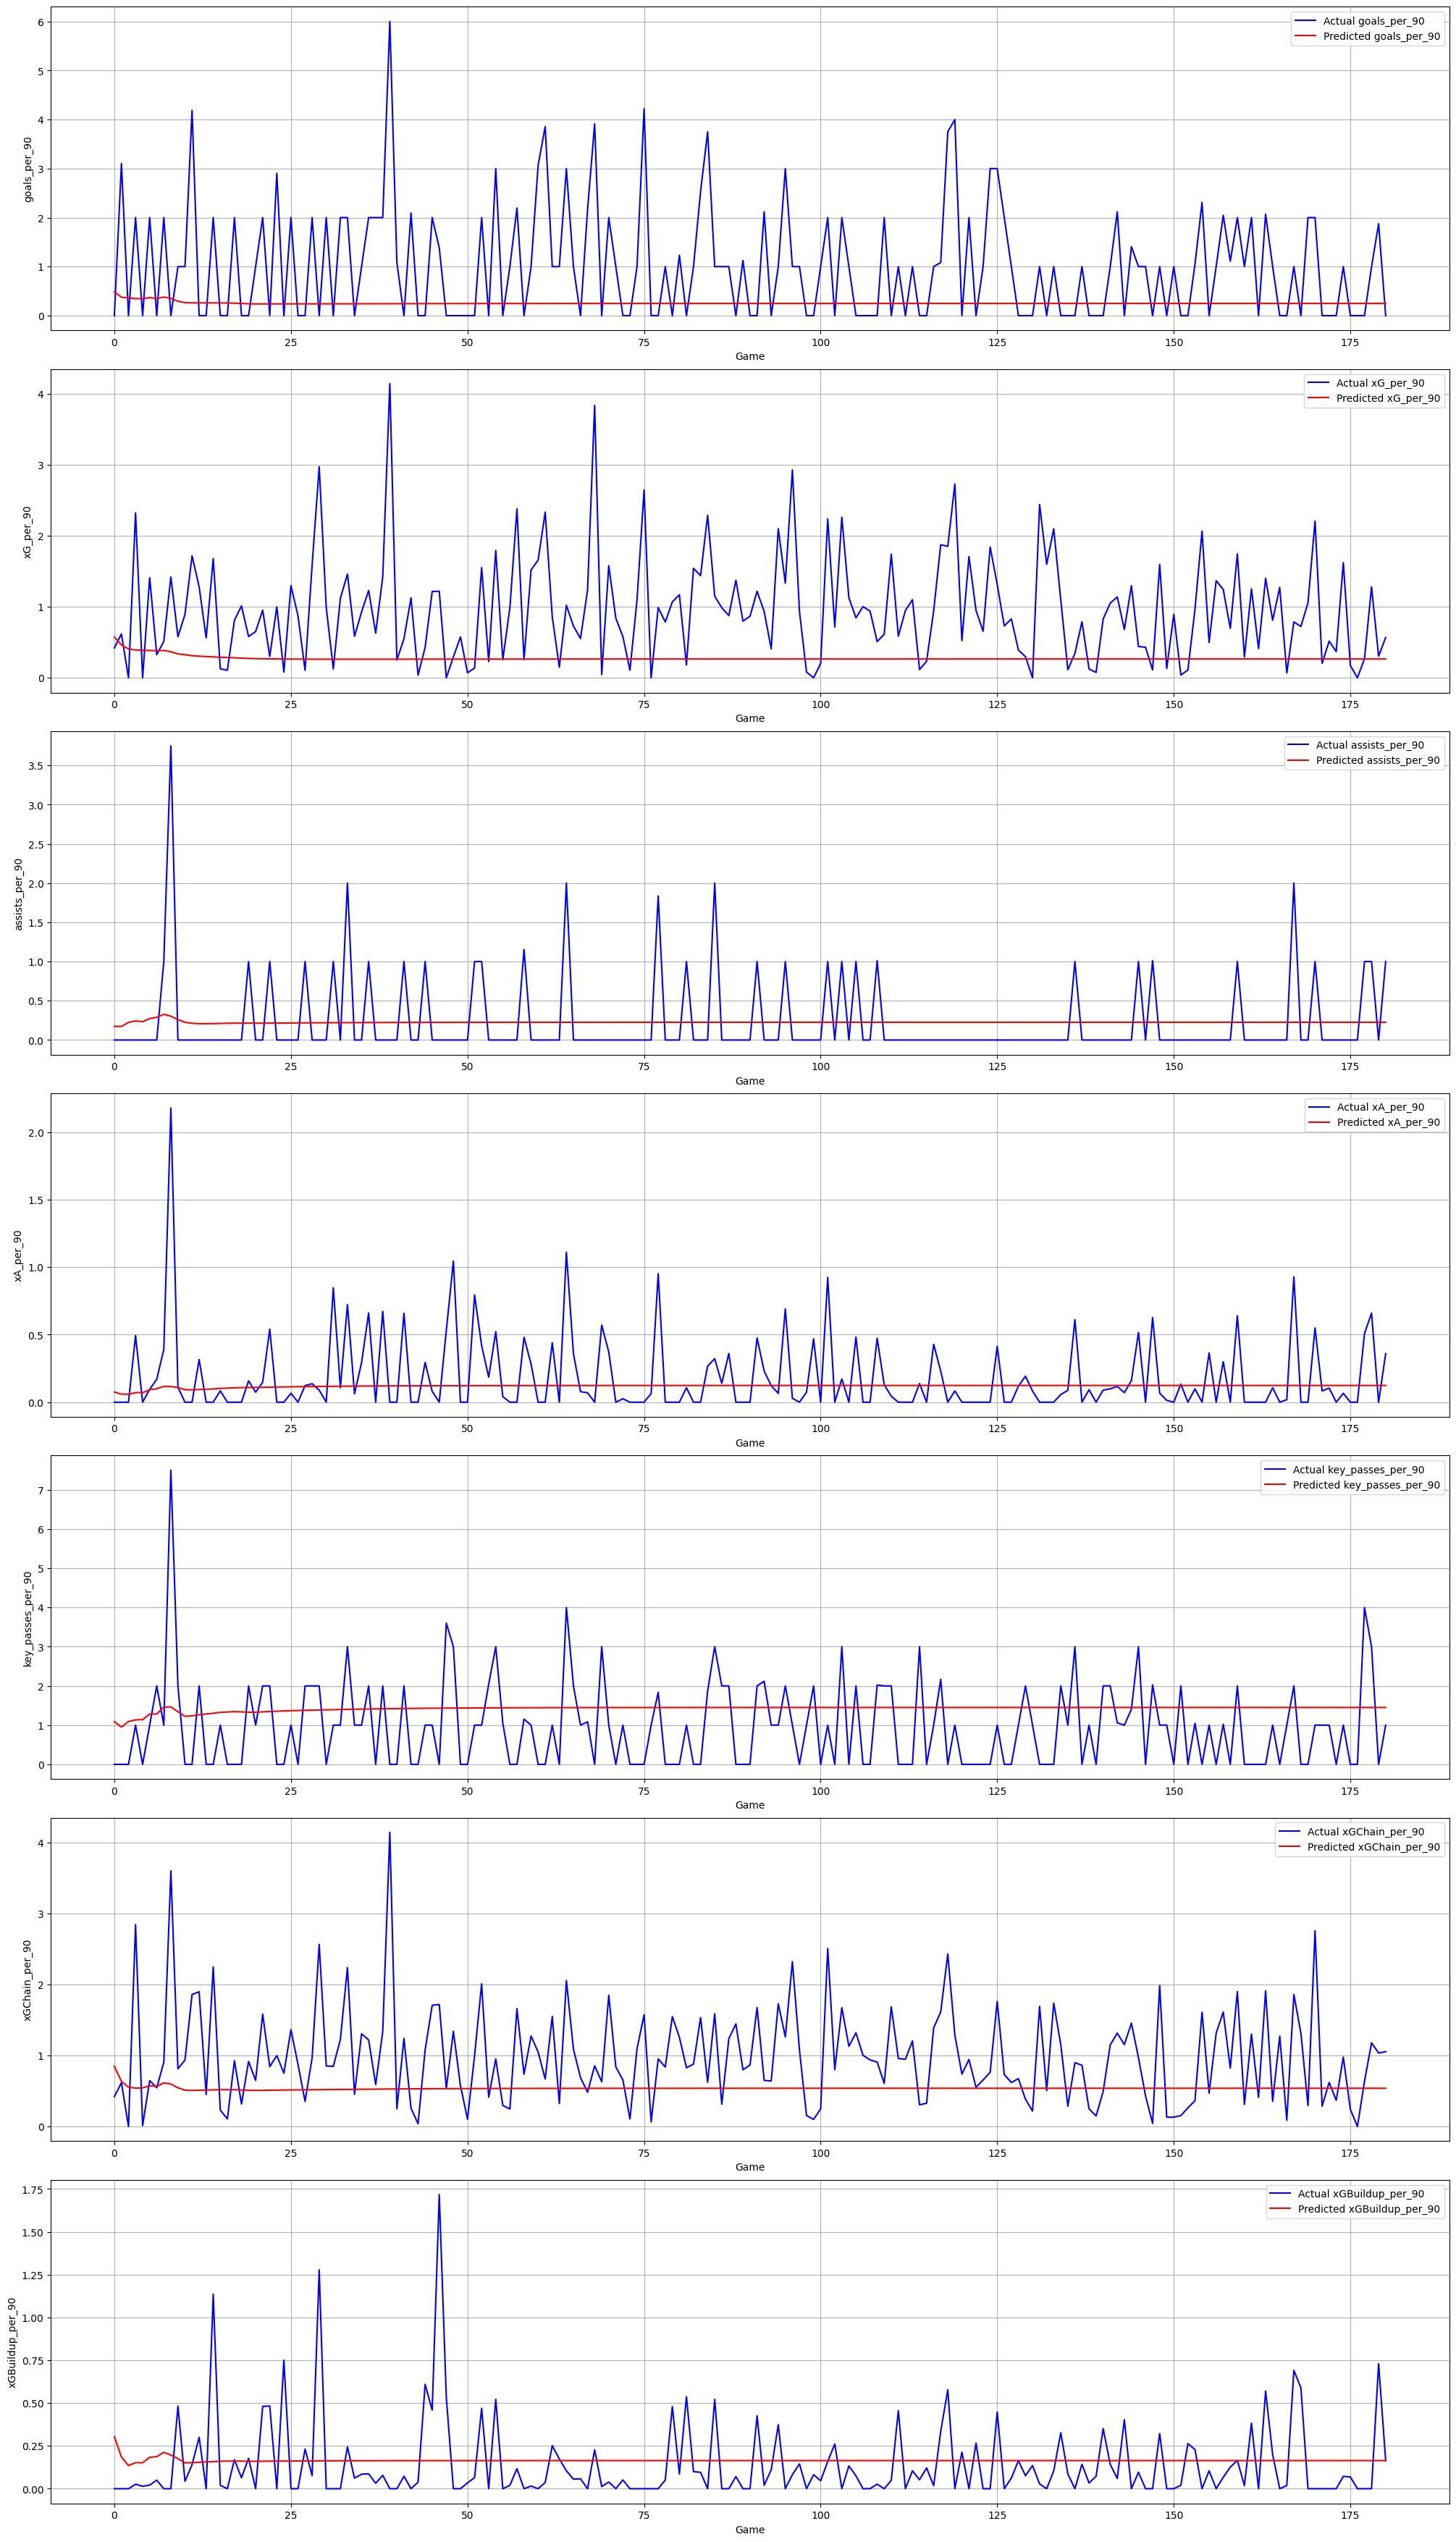

In [12]:
# See how model does on forecasting a specific player--Erling Haaland

haaland_df = f_stats.loc["8260"]

model.eval_model_on_player(haaland_df)